In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import scipy.stats as stats
import statsmodels.stats.multitest

In [2]:
normalized_bulk_seq = pd.read_csv(
    "/Users/michael/Data/Penelope_data/PL01_raw_matrix_NORMALIZED.csv", index_col=0
)
normalized_bulk_seq = normalized_bulk_seq.drop(
    columns=["CML333_1091/1092_1", "CML333_1091/1092_2"]
)
normalized_bulk_seq

,M162W_1095/1096_1,M162W_1095/1096_2,Oh7B_1097/1098_1,Oh7B_1097/1098_2,Oh7B_1097/1098_3,NC350_1099/1100_1,NC350_1099/1100_2,CML322_1101/1102_1,CML322_1101/1102_2,CML322_1101/1102_3,...,Oh43_1075/1076_3,Il14H_1077/1078_1,Il14H_1077/1078_2,Il14H_1077/1078_3,Hp301_1081/1082_1,Hp301_1081/1082_2,Hp301_1081/1082_3,NC358_1089/1090_1,NC358_1089/1090_2,NC358_1089/1090_3
GRMZM2G059865,252.14371,361.433861,136.969766,121.485461,178.290510,247.324553,176.991830,261.523141,227.948373,200.285629,...,198.093543,566.594329,383.607345,358.354337,198.552874,231.652225,213.691362,246.848020,216.414606,255.519314
GRMZM5G888250,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GRMZM2G093344,0.00000,0.762519,0.000000,0.899892,0.891453,0.792707,2.107046,1.076227,0.000000,0.000000,...,0.000000,0.927323,0.000000,3.719941,1.225635,0.000000,0.000000,0.000000,0.000000,0.000000
GRMZM2G093399,4.92789,7.625187,8.238783,13.498385,8.023073,2.378121,1.053523,3.228681,4.652008,3.708993,...,0.000000,0.000000,0.000000,0.000000,11.030715,8.986509,9.358746,7.260236,3.606910,9.642238
GRMZM5G809743,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.053523,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GRMZM5G855343,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GRMZM2G054501,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AC191109.3_FG001,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GRMZM2G372364,14.78367,20.588005,21.626805,26.096877,21.394861,15.854138,12.642274,9.686042,23.260038,22.253959,...,13.487220,43.584179,33.519088,32.239491,4.902540,9.985010,9.358746,21.780708,22.543188,15.668637


In [3]:
bulk_seq_summary = pd.read_csv(
    "/Users/michael/Data/Penelope_data/WN20NAM_streamlined_with_bins.csv",
    index_col=0,
)
bulk_seq_summary

,NAM_line,Avg_IM_Width,IM_size_binned,KRN_binned,KRN
ID,,,,,
1069_1070,B104,357.26,2.0,2.0,13.27
1122_1123,B73,435.52,3.0,3.0,17.27
1110_1111,CML277,357.66,2.0,1.0,10.94
1101_1102,CML322,367.56,2.0,3.0,15.44
1081_1082,Hp301,324.03,1.0,2.0,13.11
1077_1078,Il14H,393.39,3.0,2.0,13.15
1095_1096,M162W,310.06,1.0,2.0,14.04
1067_1068,Mo17,306.62,1.0,1.0,10.57
1112_1113,Mo18W,382.17,3.0,2.0,14.39


In [4]:
NAM_line_list = bulk_seq_summary["NAM_line"].to_list()
NAM_list_of_avg_meristem_sizes = bulk_seq_summary["Avg_IM_Width"]
kernel_row_number_list = bulk_seq_summary["KRN"]
kernel_row_number_list.index = NAM_line_list
NAM_list_of_avg_meristem_sizes.index = NAM_line_list

In [5]:
NAM_list_of_avg_meristem_sizes

B104      357.26
B73       435.52
CML277    357.66
CML322    367.56
Hp301     324.03
Il14H     393.39
M162W     310.06
Mo17      306.62
Mo18W     382.17
NC350     460.34
NC358     298.91
Oh43      311.18
Oh7B      360.06
P39       354.25
Tzi8      416.33
Name: Avg_IM_Width, dtype: float64

In [6]:
NAM_line_list

['B104',
 'B73',
 'CML277',
 'CML322',
 'Hp301',
 'Il14H',
 'M162W',
 'Mo17',
 'Mo18W',
 'NC350',
 'NC358',
 'Oh43',
 'Oh7B',
 'P39',
 'Tzi8']

In [7]:
normalized_mean_values_of_each_landrace = pd.DataFrame(index=normalized_bulk_seq.index)
for landrace in NAM_line_list:
    normalized_mean_values_of_each_landrace[landrace] = (
        normalized_bulk_seq.filter(like=landrace, axis=1).mean(axis=1).values
    )

In [8]:
normalized_mean_values_of_each_landrace

,B104,B73,CML277,CML322,Hp301,Il14H,M162W,Mo17,Mo18W,NC350,NC358,Oh43,Oh7B,P39,Tzi8
GRMZM2G059865,36.911356,308.003602,263.095125,229.919048,214.632154,436.185337,306.788786,44.403649,125.104655,212.158191,239.593980,200.039115,145.581912,230.295205,330.274863
GRMZM5G888250,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GRMZM2G093344,0.572864,0.352122,0.551458,0.358742,0.408545,1.549088,0.381259,0.955540,0.782535,1.449876,0.000000,0.302318,0.597115,0.444681,0.000000
GRMZM2G093399,0.000000,0.315388,7.531771,3.863227,9.791990,0.000000,6.276539,0.000000,0.000000,1.715822,6.836461,0.000000,9.920080,0.000000,4.997008
GRMZM5G809743,0.000000,0.000000,0.294490,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.526761,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GRMZM5G855343,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GRMZM2G054501,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AC191109.3_FG001,0.000000,0.000000,0.264669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.889362,0.000000
GRMZM2G372364,17.007314,20.480881,14.293619,18.400013,8.082099,36.447586,17.685838,21.973180,21.262103,14.248206,19.997511,13.811456,23.039514,39.810154,33.097879


In [9]:
pearson_correlation_with_meristem_size = (
    normalized_mean_values_of_each_landrace.corrwith(
        other=NAM_list_of_avg_meristem_sizes, axis=1, method="spearman"
    )
)
pearson_correlation_with_meristem_size = pd.DataFrame(
    pearson_correlation_with_meristem_size,
    columns=["Pearson Correlation with Meristem Width"],
)
pearson_correlation_with_meristem_size.sort_values(
    by="Pearson Correlation with Meristem Width", ascending=False
)

/Users/michael/miniconda3/envs/Luke_terrace/lib/python3.13/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,Pearson Correlation with Meristem Width
GRMZM2G106766,0.821429
GRMZM2G107745,0.817857
GRMZM2G101181,0.807143
GRMZM2G077632,0.800000
GRMZM2G481021,0.798099
...,...
RPL2.A.2,NaN
GRMZM5G866064,NaN
GRMZM5G855343,NaN
GRMZM2G054501,NaN


In [10]:
pearson_correlation_with_meristem_size[
    "Pearson Correlation with Meristem Width"
].dropna()

GRMZM2G059865       0.275000
GRMZM2G093344       0.246649
GRMZM2G093399      -0.077460
GRMZM5G809743       0.338062
GRMZM5G833153       0.591608
                      ...   
RPS3.1             -0.325000
NDHD                0.021506
PSAC               -0.371154
AC191109.3_FG001   -0.096589
GRMZM2G372364       0.192857
Name: Pearson Correlation with Meristem Width, Length: 28133, dtype: float64

(array([   0.,  200.,  400.,  600.,  800., 1000., 1200.]),
 [Text(0, 0.0, '0'),
  Text(0, 200.0, '200'),
  Text(0, 400.0, '400'),
  Text(0, 600.0, '600'),
  Text(0, 800.0, '800'),
  Text(0, 1000.0, '1000'),
  Text(0, 1200.0, '1200')])

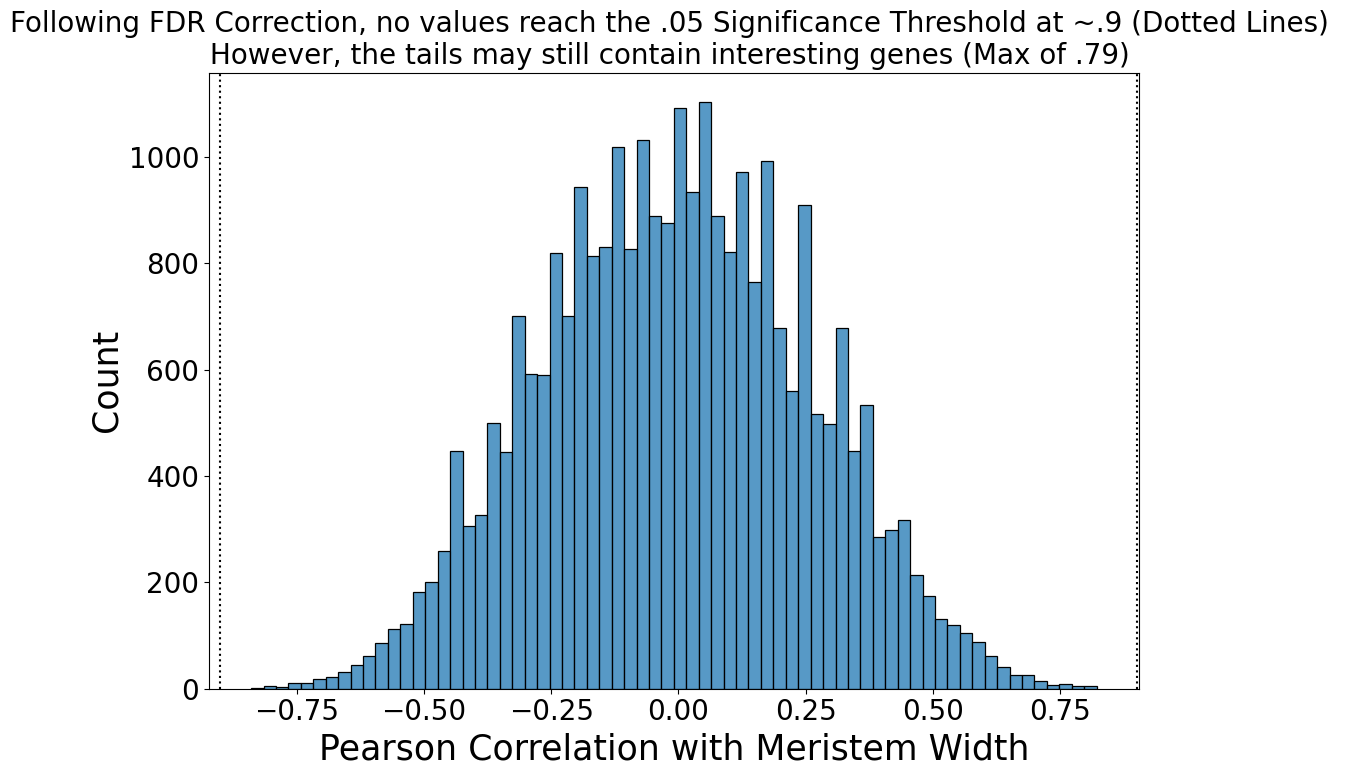

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.histplot(
    data=pearson_correlation_with_meristem_size,
    x="Pearson Correlation with Meristem Width",
)
plt.axvline(x=0.9, linestyle=":", color="k")
plt.axvline(x=-0.9, linestyle=":", color="k")
plt.ylabel("Count", fontsize=25)
plt.xlabel("Pearson Correlation with Meristem Width", fontsize=25)
plt.title(
    "Following FDR Correction, no values reach the .05 Significance Threshold at ~.9 (Dotted Lines) \n However, the tails may still contain interesting genes (Max of .79)  ",
    fontsize=20,
)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

In [12]:
pearson_correlation_with_krn = normalized_mean_values_of_each_landrace.corrwith(
    other=kernel_row_number_list, axis=1, method="spearman"
)
pearson_correlation_with_krn = pd.DataFrame(
    pearson_correlation_with_krn, columns=["Pearson Correlation with "]
)

/Users/michael/miniconda3/envs/Luke_terrace/lib/python3.13/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


In [13]:
kernel_row_number_list

B104      13.27
B73       17.27
CML277    10.94
CML322    15.44
Hp301     13.11
Il14H     13.15
M162W     14.04
Mo17      10.57
Mo18W     14.39
NC350     13.66
NC358     12.09
Oh43      14.55
Oh7B      13.80
P39       13.31
Tzi8      14.09
Name: KRN, dtype: float64

In [14]:
corr_and_p_value_list = []
for land_race_gene in normalized_mean_values_of_each_landrace.iterrows():
    current_correlation, current_pvalue = stats.spearmanr(
        land_race_gene[1], NAM_list_of_avg_meristem_sizes
    )
    current_values_to_append = [current_correlation, current_pvalue]
    corr_and_p_value_list.append(current_values_to_append)

/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_95338/1998415884.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  current_correlation, current_pvalue = stats.spearmanr(


In [15]:
stats_and_pearson_calculated = pd.DataFrame(
    index=pearson_correlation_with_meristem_size.index,
    data=corr_and_p_value_list,
    columns=["Pearson Correlation with Meristem Width", "P Value"],
)
stats_and_pearson_calculated = stats_and_pearson_calculated.dropna()

In [16]:
stats_and_pearson_calculated.loc["GRMZM2G009413", "P Value"] = 0.00001

In [17]:
reject, corrected = statsmodels.stats.multitest.fdrcorrection(
    stats_and_pearson_calculated["P Value"]
)

In [18]:
stats_and_pearson_calculated["Corrected P Value"] = corrected

In [19]:
stats_and_pearson_calculated.sort_values(by="P Value")

,Pearson Correlation with Meristem Width,P Value,Corrected P Value
GRMZM2G009413,0.635714,0.000010,0.281330
GRMZM2G010831,-0.839286,0.000091,0.849135
GRMZM2G106766,0.821429,0.000173,0.849135
GRMZM2G039961,-0.820704,0.000177,0.849135
GRMZM2G107745,0.817857,0.000195,0.849135
...,...,...,...
GRMZM2G053396,0.000000,1.000000,1.000000
GRMZM2G040702,0.000000,1.000000,1.000000
CISZOG1,0.000000,1.000000,1.000000
GRMZM2G161483,0.000000,1.000000,1.000000


In [20]:
stats_and_pearson_calculated.to_csv(
    "/Users/michael/Data/Penelope_data/meristem_width_spearman_correlation_and_p_values.csv"
)

<Axes: xlabel='P Value', ylabel='Count'>

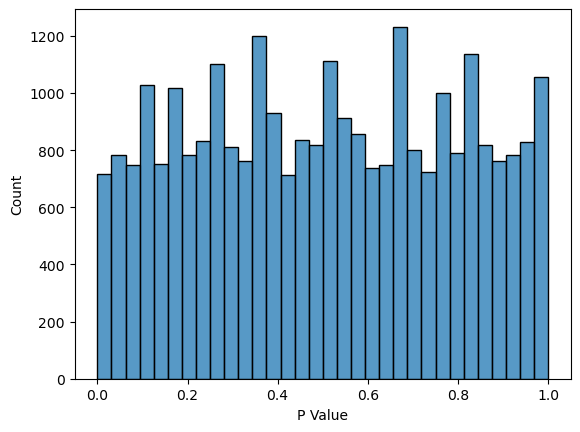

In [21]:
sns.histplot(data=stats_and_pearson_calculated, x="P Value")

In [22]:
krn_stats_and_pearson = []
for land_race_gene in normalized_mean_values_of_each_landrace.iterrows():
    current_correlation, current_pvalue = stats.spearmanr(
        land_race_gene[1], kernel_row_number_list
    )
    current_values_to_append = [current_correlation, current_pvalue]
    krn_stats_and_pearson.append(current_values_to_append)

/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_95338/3122418045.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  current_correlation, current_pvalue = stats.spearmanr(


In [23]:
krn_stats_and_pearson = pd.DataFrame(
    index=pearson_correlation_with_meristem_size.index,
    data=krn_stats_and_pearson,
    columns=["Pearson Correlation with KRN", "P Value"],
)
krn_stats_and_pearson = krn_stats_and_pearson.dropna()

In [24]:
krn_stats_and_pearson.sort_values(by="Pearson Correlation with KRN", ascending=False)

,Pearson Correlation with KRN,P Value
GRMZM2G105283,0.817857,0.000195
GRMZM2G129973,0.814286,0.000219
GRMZM2G108739,0.814286,0.000219
GRMZM2G014610,0.803769,0.000305
GRMZM2G009719,0.803571,0.000307
...,...,...
GRMZM2G313867,-0.807143,0.000275
GRMZM2G433598,-0.807679,0.000271
GRMZM2G096824,-0.814286,0.000219
GRMZM2G098679,-0.837872,0.000096


In [25]:
reject, corrected = statsmodels.stats.multitest.fdrcorrection(
    krn_stats_and_pearson["P Value"]
)

In [26]:
krn_stats_and_pearson["Corrected P Value"] = corrected

In [27]:
krn_stats_and_pearson.sort_values(by="P Value")

,Pearson Correlation with KRN,P Value,Corrected P Value
GRMZM2G006884,-0.858037,0.000043,0.764765
GRMZM2G098679,-0.837872,0.000096,0.764765
GRMZM2G105283,0.817857,0.000195,0.764765
GRMZM2G096824,-0.814286,0.000219,0.764765
GRMZM2G108739,0.814286,0.000219,0.764765
...,...,...,...
AC206165.3_FG019,0.000000,1.000000,1.000000
GRMZM2G032628,0.000000,1.000000,1.000000
GRMZM2G041238,0.000000,1.000000,1.000000
GRMZM2G504293,0.000000,1.000000,1.000000


In [28]:
krn_stats_and_pearson.to_csv(
    "/Users/michael/Data/Penelope_data/krn_spearman_correlation_and_p_values.csv"
)

(array([   0.,  200.,  400.,  600.,  800., 1000., 1200., 1400.]),
 [Text(0, 0.0, '0'),
  Text(0, 200.0, '200'),
  Text(0, 400.0, '400'),
  Text(0, 600.0, '600'),
  Text(0, 800.0, '800'),
  Text(0, 1000.0, '1000'),
  Text(0, 1200.0, '1200'),
  Text(0, 1400.0, '1400')])

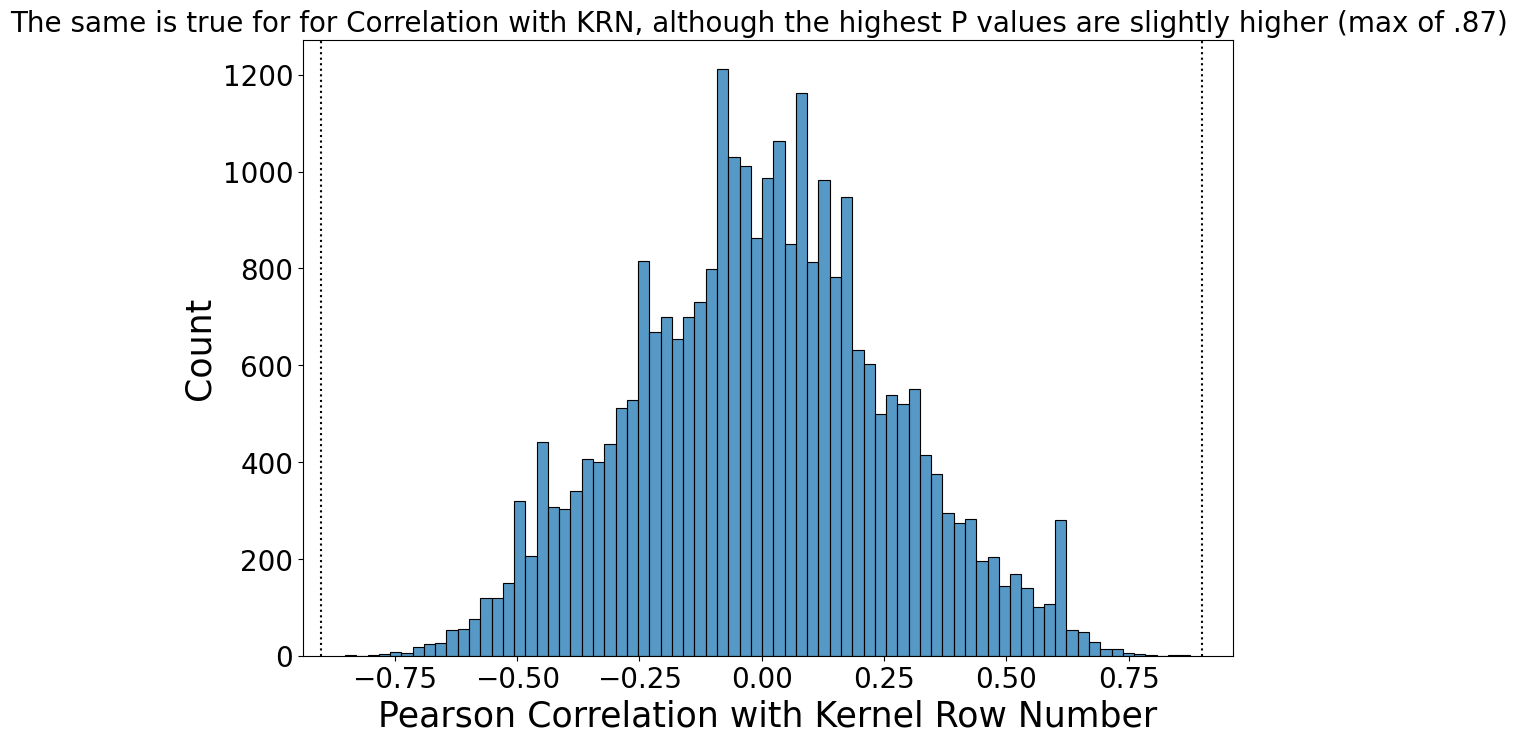

In [27]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.histplot(data=krn_stats_and_pearson, x="Pearson Correlation with KRN")
plt.axvline(x=0.9, linestyle=":", color="k")
plt.axvline(x=-0.9, linestyle=":", color="k")
plt.ylabel("Count", fontsize=25)
plt.xlabel("Pearson Correlation with Kernel Row Number", fontsize=25)
plt.title(
    "The same is true for for Correlation with KRN, although the highest P values are slightly higher (max of .87)  ",
    fontsize=20,
)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

In [28]:
def get_go_annotations_as_panda(species):
    import pandas as pd

    ## TAXA_ID to species_name
    if type(species) == int:
        mapper = pd.read_csv(
            "/home/passala/Gene_duplication_project/Generated_tables/Time_Savers/Species_name_resolver.csv"
        )
        species = mapper["Common Name"].loc[mapper["Taxa ID"] == species].item()

    ## Get file_location
    file_location = "/data/CoCoCoNet/gene2go/" + species + "_gene2go.csv"
    original_csv = pd.read_csv(file_location, sep=" ")
    if len(original_csv) == 0:
        raise NameError("No Annotations for this Species :(")
    original_csv = original_csv.dropna()
    original_csv["Present"] = 1
    matrixed_version = original_csv.pivot(
        index="NetworkIDs", columns="GO_term", values="Present"
    )
    filled_matrixed_version = matrixed_version.fillna(value=0)
    return filled_matrixed_version

In [29]:
def generate_contigency_tables(go_annotations, gene_list):
    gene_list = list(set(go_annotations.index) & set(gene_list))
    background_distribution_num_genes_annotated_with_go_term = go_annotations.sum(
        axis=0
    )
    background_dipstribution_num_genes_that_lack_go_term = (
        go_annotations.shape[0]
        - background_distribution_num_genes_annotated_with_go_term
    )
    annotation_subset_to_genes_in_list = go_annotations.loc[gene_list]
    go_subset_distribution_num_genes_annotatated_with_go_term = (
        annotation_subset_to_genes_in_list.sum(axis=0)
    )
    go_subset_distribution_num_genes_that_lack_go_term = (
        annotation_subset_to_genes_in_list.shape[0]
        - go_subset_distribution_num_genes_annotatated_with_go_term
    )

    all_go_contingency_tables = []
    i = 0
    for term_of_go in background_distribution_num_genes_annotated_with_go_term:
        contig_table = [
            [
                (
                    term_of_go
                    - go_subset_distribution_num_genes_annotatated_with_go_term[i]
                ),
                go_subset_distribution_num_genes_annotatated_with_go_term[i],
            ],
            [
                (
                    background_dipstribution_num_genes_that_lack_go_term[i]
                    - go_subset_distribution_num_genes_that_lack_go_term[i]
                ),
                go_subset_distribution_num_genes_that_lack_go_term[i],
            ],
        ]
        all_go_contingency_tables.append(contig_table)
        i += 1
    return all_go_contingency_tables

In [ ]:
## Penelope both sides otherwise comment out

# stats_and_pearson_calculated['Pearson Correlation with Meristem Width'] = abs(stats_and_pearson_calculated['Pearson Correlation with Meristem Width'])
# stats_and_pearson_calculated.sort_values(by = 'Pearson Correlation with Meristem Width',ascending = False)[:3000]

# krn_stats_and_pearson['Pearson Correlation with KRN'] = abs(krn_stats_and_pearson['Pearson Correlation with KRN'])

In [ ]:
# normal, then abs, then neg
# list_of_high_genes = stats_and_pearson_calculated.sort_values(by = 'Pearson Correlation with Meristem Width',ascending = False)[:1750].index.to_list()
# list_of_high_genes = stats_and_pearson_calculated.sort_values(by = 'Pearson Correlation with Meristem Width',ascending = False)[:3000].index.to_list()
# list_of_high_genes = stats_and_pearson_calculated.sort_values(by = 'Pearson Correlation with Meristem Width',ascending = False)[-800:].index.to_list()


# KRN Association
# list_of_high_genes = krn_stats_and_pearson.sort_values(by = 'Pearson Correlation with KRN',ascending = False)[:2000].index.to_list()
list_of_high_genes = krn_stats_and_pearson.sort_values(
    by="Pearson Correlation with KRN", ascending=False
)[-1500:].index.to_list()

In [ ]:
krn_stats_and_pearson.sort_values(by="Pearson Correlation with KRN", ascending=False)[
    -1500:
]

In [ ]:
stats_and_pearson_calculated.sort_values(
    by="Pearson Correlation with Meristem Width", ascending=False
)[-1750:]

In [ ]:
maize_go = get_go_annotations_as_panda("maize")
maize_go

In [ ]:
maize_converter = pd.read_csv("/data/CoCoCoNet/geneInfo/maize_info.csv")
maize_converter["Synonyms"] = maize_converter["Synonyms"].str.split("|")

In [ ]:
maize_converter = maize_converter.dropna(subset=["Synonyms"])
maize_converter

In [ ]:
maize_converter["Synonyms"] = list(zip(*maize_converter["Synonyms"].to_list()))[1]
maize_converter_for_bruno = maize_converter[["GeneSymbol", "Synonyms", "EnsemblID"]]
maize_converter = maize_converter[["Synonyms", "EnsemblID"]]
maize_converter

In [ ]:
# maize_converter_for_bruno.to_csv('/home/passala/Gene_duplication_project/Code/Bruno_maize_sorghum_project/Stuff_to_send_bruno/maize_gene_conversion_list.csv')

In [ ]:
list(set(maize_go.index) & set(list_of_high_genes))

In [ ]:
panda_of_high_genes = pd.DataFrame(data=list_of_high_genes, columns=["Genes"])

In [ ]:
panda_of_high_genes

In [ ]:
panda_genes_converted = panda_of_high_genes.merge(
    how="left", right=maize_converter, left_on="Genes", right_on="Synonyms"
)
panda_genes_converted = panda_genes_converted.dropna(subset=["EnsemblID"])

genes_for_enrichment = panda_genes_converted["EnsemblID"].to_list()

In [ ]:
high_meristem_contig_tables = generate_contigency_tables(
    go_annotations=maize_go, gene_list=genes_for_enrichment
)

In [ ]:
type(high_meristem_contig_tables)

In [ ]:
list_of_p_values_go_change = []
for table in high_meristem_contig_tables:
    odds, p_value = stats.fisher_exact(table=table, alternative="less")
    list_of_p_values_go_change.append(p_value)

In [ ]:
go_set_refiner = pd.DataFrame(
    data=list_of_p_values_go_change, index=maize_go.columns, columns=["P_value"]
)
go_set_refiner

In [ ]:
go_group_size = maize_go.sum(axis=0) > 5
go_group_size = go_group_size.to_list()
maize_go_transposed = maize_go.T
big_enough_go_groups = maize_go_transposed.loc[go_group_size]
big_enough_go_groups

In [ ]:
go_set_refiner = go_set_refiner.loc[
    go_set_refiner.index.isin(big_enough_go_groups.index)
]

In [ ]:
go_set_refiner.at["GO:0000003", "P_value"] = 0.00000001

In [ ]:
import GO_Enrichment_Calculator as gr

In [ ]:
gr.tester(
    go_terms_with_P_value=go_set_refiner, alpha=0.1, Include_rejected_boolean_array=True
)

In [ ]:
rejected, corrected_pvalues = statsmodels.stats.multitest.fdrcorrection(
    pvals=go_set_refiner["P_value"].to_list(), alpha=0.05
)
corrected_pvalues = corrected_pvalues.tolist()
go_enrichment_results = pd.DataFrame(
    corrected_pvalues, index=go_set_refiner.index, columns=["P_value"]
)

In [ ]:
go_enrichment_results = go_enrichment_results.sort_values("P_value", ascending=False)
# go_enrichment_results.tail(20).to_csv('/home/passala/Gene_duplication_project/Code/Penelope_maize_meristem_project/Stuff_to_send_to_Penelope/negatively_correlated_go_results.csv')

In [ ]:
go_enrichment_results.tail(20)

In [ ]:
panda_genes_converted

In [ ]:
# genes_in_group_of_interest = big_enough_go_groups.T.loc[(big_enough_go_groups.T['GO:0009966'] ==1) | (big_enough_go_groups.T['GO:0048583'] == 1) | (big_enough_go_groups.T['GO:0080134'] == 1) | (big_enough_go_groups.T['GO:0031347'] == 1)]
# genes_in_group_of_interest = big_enough_go_groups.T.loc[big_enough_go_groups.T['GO:0048608'] == 1]
# genes_in_group_of_interest = big_enough_go_groups.T.loc[(big_enough_go_groups.T['GO:0048731'] ==1) | (big_enough_go_groups.T['GO:0032501'] == 1) | (big_enough_go_groups.T['GO:0048856'] == 1) | (big_enough_go_groups.T['GO:0007275'] == 1) | (big_enough_go_groups.T['GO:0009791'] == 1) | (big_enough_go_groups.T['GO:0003006'] == 1)]

In [ ]:
genes_in_group_of_interest

In [ ]:
list_of_significant_genes = genes_in_group_of_interest.loc[
    genes_in_group_of_interest.index.isin(genes_for_enrichment)
].index.to_list()

In [ ]:
list_of_significant_genes_in_grm_format = panda_genes_converted.loc[
    panda_genes_converted["EnsemblID"].isin(list_of_significant_genes)
]
list_of_significant_genes_in_grm_format = list_of_significant_genes_in_grm_format[
    "Genes"
].to_list()

In [ ]:
list_of_significant_genes_in_grm_format

In [ ]:
significantly_annotated_genes = stats_and_pearson_calculated.loc[
    stats_and_pearson_calculated.index.isin(list_of_significant_genes_in_grm_format)
]

In [ ]:
# significantly_annotated_genes.to_csv('/home/passala/Gene_duplication_project/Code/Penelope_maize_meristem_project/Stuff_to_send_to_Penelope/abs_value_associated_genes.csv')

In [ ]:
sns.histplot(
    go_enrichment_results,
)
plt.ylim(0, 1000)

In [ ]:
uncorrected_values = pd.DataFrame(data=list_of_p_values_go_change, columns=["P Value"])

In [ ]:
sns.histplot(uncorrected_values)

In [ ]:
maize_go